importing the dependencies

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

Data Collecting and processing

In [41]:
# loading the data from csv file to panda dataframe
df = pd.read_csv("/content/car data.csv")

In [42]:
# inspecting the first 5 rows of the dataframe
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [43]:
# checking the rows and columns
df.shape

(301, 9)

In [44]:
# getting some informtion about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [45]:
# checking the missing value
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [46]:
# checking the distribution of categorical data
print(df.Fuel_Type.value_counts())
print(df.Seller_Type.value_counts())
print(df.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


Encoding the categorical data

In [47]:
# encoding "fuel_type" column
df['Fuel_Type']= df['Fuel_Type'].replace({
    'Petrol':0,
    'Diesel':1,
    'CNG':2
    }).astype(int)

# encoding "seller_type" column
df['Seller_Type'] = df['Seller_Type'].replace({
    'Dealer':0,
    'Individual':1
}).astype(int)


# encoding "Transmission" column
df['Transmission'] = df['Transmission'].replace({
    'Manual':0,
    'Automatic':1
}).astype(int)

/tmp/ipykernel_14319/3528035478.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Fuel_Type']= df['Fuel_Type'].replace({
/tmp/ipykernel_14319/3528035478.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Seller_Type'] = df['Seller_Type'].replace({
/tmp/ipykernel_14319/3528035478.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('

In [48]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


Splitting the Data and Traget

In [49]:
X= df.drop(['Car_Name','Selling_Price'], axis=1)
Y= df['Selling_Price']

In [50]:
Y

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60
...,...
296,9.50
297,4.00
298,3.35
299,11.50


Splitting the data into a training dat and test data

In [51]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=2)

Model Training


1. LinearRegression

In [64]:
# loading the linear model
lin_reg = LinearRegression()
lin_reg.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [65]:
# prediction on training data
Y_pred = lin_reg.predict(X_train)

# R Squared error
error_score = metrics.r2_score(Y_train,Y_pred)
print("R Squared error:", error_score)


R Squared error: 0.8799451660493711


Visualize the Actual price and pred price


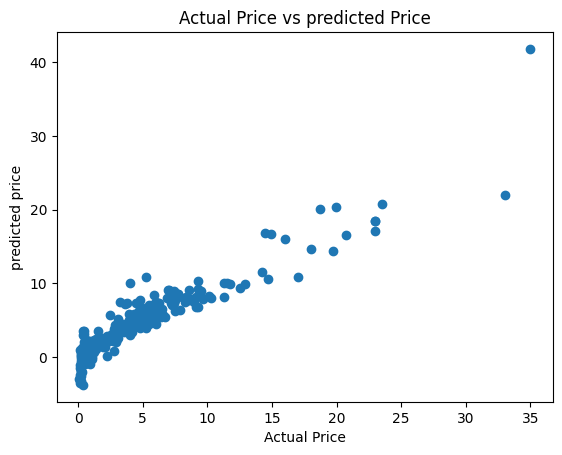

In [58]:
plt.scatter(Y_train,Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("predicted price")
plt.title("Actual Price vs predicted Price")
plt.show()

In [62]:
# prediction on test data
Y_tpred = lin_reg.predict(X_test)

# R Squared error
error_score = metrics.r2_score(Y_test,Y_tpred)
print("R Squared error:", error_score)

R Squared error: 0.8365766715027051


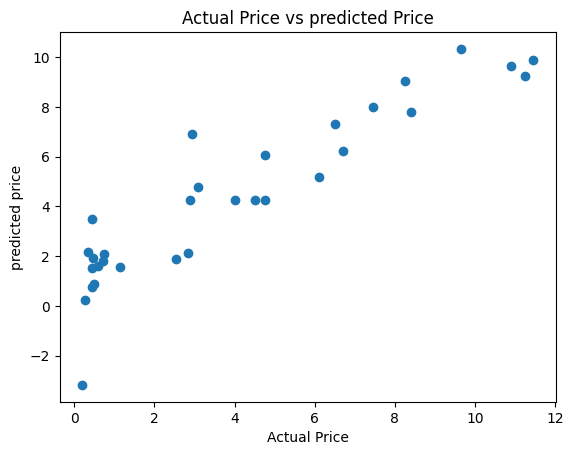

In [63]:
plt.scatter(Y_test,Y_tpred)
plt.xlabel("Actual Price")
plt.ylabel("predicted price")
plt.title("Actual Price vs predicted Price")
plt.show()

2. Lasso regression

In [66]:
# loading the lasso regression model
las_reg = Lasso()
las_reg.fit(X_train,Y_train)

Lasso()

Model Evaluation

In [67]:
# prediction on training data
Y_pred = las_reg.predict(X_train)

# R Squared error
error_score = metrics.r2_score(Y_train,Y_pred)
print("R Squared error:", error_score)


R Squared error: 0.8427856123435794


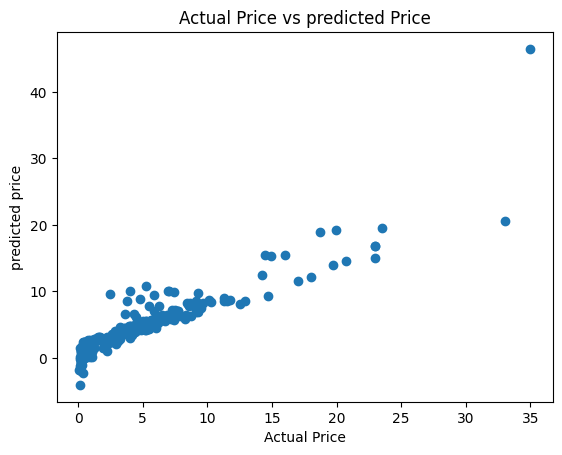

In [68]:
plt.scatter(Y_train,Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("predicted price")
plt.title("Actual Price vs predicted Price")
plt.show()

In [69]:
# prediction on test data
Y_tpred = las_reg.predict(X_test)

# R Squared error
error_score = metrics.r2_score(Y_test,Y_tpred)
print("R Squared error:", error_score)

R Squared error: 0.8709167941173195


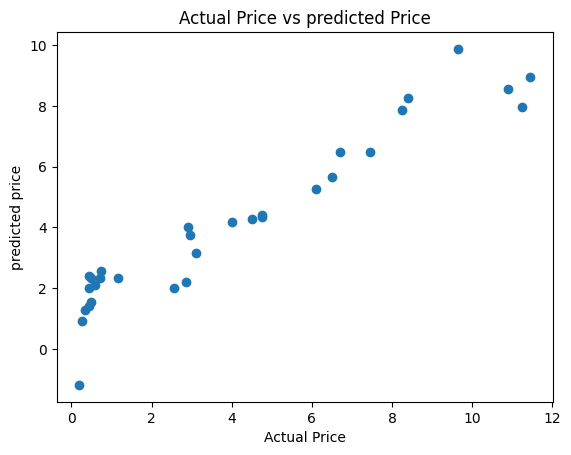

In [70]:
plt.scatter(Y_test,Y_tpred)
plt.xlabel("Actual Price")
plt.ylabel("predicted price")
plt.title("Actual Price vs predicted Price")
plt.show()